<a href="https://colab.research.google.com/github/justwannachill/NM/blob/main/%D0%9B%D0%B0%D0%B15%D0%A8%D0%B8%D0%BB%D0%BE%D0%B2_ipynb%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Завантажити датасет з Kaggle.
мпортувати дані у середовище Python (Jupyter Notebook або Google Colab).
Ознайомитися зі структурою датасету (head(), info(), describe()).
Попередня обробка даних
-Перетворити колонку з датою у формат datetime.
-Відсортувати дані за датою.
-Встановити дату як індекс часового ряду.
-Перевірити наявність пропущених значень та за необхідності обробити їх.
Дослідницький аналіз даних (EDA)
-Побудувати графік зміни температури у часі.
-Побудувати ковзне середнє значення температури.
-Побудувати гістограму розподілу температури.
-Побудувати boxplot для виявлення можливих викидів.
-Аналіз автокореляції
Побудувати графік автокореляційної функції (ACF).
Побудувати графік часткової автокореляції (PACF).
-Проаналізувати залежність значень часового ряду від попередніх періодів.
6.Підготовка даних для моделювання
-Розділити дані на тренувальну та тестову вибірки (наприклад, 80% / 20%).
Побудувати щонайменше три моделі прогнозування:
-ARIMA (класична статистична модель);
-Prophet (модель прогнозування часових рядів від Meta);
-LSTM (нейронна мережа для послідовних даних).
Оцінка моделей Для кожної моделі обчислити метрики:
-MAE (Mean Absolute Error)
-RMSE (Root Mean Squared Error)
-MAPE (Mean Absolute Percentage Error)
8.Візуалізація результатів
-Побудувати графіки прогнозованих та фактичних значень.
-Побудувати порівняльний графік прогнозів усіх моделей.
-Порівняння моделей
-Створити таблицю з метриками точності.
9.Визначити модель, яка показала найкращий результат.

In [ ]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import MinMaxScaler

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

warnings.filterwarnings("ignore")
plt.style.use("default")

In [ ]:
from google.colab import files
import os
uploaded = files.upload()

Saving kaggel_weather_2013_to_2024.csv to kaggel_weather_2013_to_2024 (1).csv


In [ ]:
df = pd.read_csv("kaggel_weather_2013_to_2024.csv")

df

,Unnamed: 0,DATE,tempmax,tempmin,temp,feelslikemax,feelslikemin,feelslike,humidity,precip,...,year-2000,weekofyear,tempmax_humidity,tempmin_humidity,temp_humidity,feelslikemax_humidity,feelslikemin_humidity,feelslike_humidity,temp_range,heat_index
0,0,4/14/2013,37.7,23.1,28.7,35.4,23.1,28.1,39.7,2.0,...,13,15,1496.69,917.07,1139.39,1405.38,917.07,1115.57,14.6,147.178118
1,1,4/15/2013,37.5,21.1,28.6,35.3,21.1,28.0,41.7,0.0,...,13,16,1563.75,879.87,1192.62,1472.01,879.87,1167.60,16.4,151.731061
2,2,4/16/2013,40.1,21.9,31.7,37.5,21.9,30.4,30.7,0.0,...,13,16,1231.07,672.33,973.19,1151.25,672.33,933.28,18.2,118.211133
3,3,4/17/2013,36.4,21.0,29.9,34.0,21.0,28.5,27.4,0.0,...,13,16,997.36,575.40,819.26,931.60,575.40,780.90,15.4,113.320354
4,4,4/18/2013,37.5,21.7,30.6,35.2,21.7,29.2,23.7,0.0,...,13,16,888.75,514.29,725.22,834.24,514.29,692.04,15.8,101.407038
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3552,3552,11/26/2024,25.8,13.6,18.6,25.8,13.6,18.6,65.9,0.0,...,24,48,1700.22,896.24,1225.74,1700.22,896.24,1225.74,12.2,242.171864
3553,3553,11/27/2024,26.2,12.5,18.4,26.2,12.5,18.4,61.0,0.0,...,24,48,1598.20,762.50,1122.40,1598.20,762.50,1122.40,13.7,236.769595
3554,3554,11/28/2024,25.8,11.5,17.9,25.8,11.5,17.9,63.1,0.0,...,24,48,1627.98,725.65,1129.49,1627.98,725.65,1129.49,14.3,243.117035
3555,3555,11/29/2024,25.0,10.6,18.0,25.0,10.6,18.0,60.0,0.0,...,24,48,1500.00,636.00,1080.00,1500.00,636.00,1080.00,14.4,237.638344


In [ ]:
df["DATE"] = pd.to_datetime(df["DATE"])

df = df.sort_values("DATE")

df = df.drop(columns=["Unnamed: 0"])

df = df.set_index("DATE")

df.head()

,tempmax,tempmin,temp,feelslikemax,feelslikemin,feelslike,humidity,precip,precipprob,precipcover,...,year-2000,weekofyear,tempmax_humidity,tempmin_humidity,temp_humidity,feelslikemax_humidity,feelslikemin_humidity,feelslike_humidity,temp_range,heat_index
DATE,,,,,,,,,,,,,,,,,,,,,
2013-04-14,37.7,23.1,28.7,35.4,23.1,28.1,39.7,2.0,100,4.17,...,13,15,1496.69,917.07,1139.39,1405.38,917.07,1115.57,14.6,147.178118
2013-04-15,37.5,21.1,28.6,35.3,21.1,28.0,41.7,0.0,0,0.00,...,13,16,1563.75,879.87,1192.62,1472.01,879.87,1167.60,16.4,151.731061
2013-04-16,40.1,21.9,31.7,37.5,21.9,30.4,30.7,0.0,0,0.00,...,13,16,1231.07,672.33,973.19,1151.25,672.33,933.28,18.2,118.211133
2013-04-17,36.4,21.0,29.9,34.0,21.0,28.5,27.4,0.0,0,0.00,...,13,16,997.36,575.40,819.26,931.60,575.40,780.90,15.4,113.320354
2013-04-18,37.5,21.7,30.6,35.2,21.7,29.2,23.7,0.0,0,0.00,...,13,16,888.75,514.29,725.22,834.24,514.29,692.04,15.8,101.407038


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3557 entries, 2013-04-14 to 2024-11-30
Data columns (total 27 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   tempmax                3557 non-null   float64
 1   tempmin                3557 non-null   float64
 2   temp                   3557 non-null   float64
 3   feelslikemax           3557 non-null   float64
 4   feelslikemin           3557 non-null   float64
 5   feelslike              3557 non-null   float64
 6   humidity               3557 non-null   float64
 7   precip                 3557 non-null   float64
 8   precipprob             3557 non-null   int64  
 9   precipcover            3557 non-null   float64
 10  windspeed              3557 non-null   float64
 11  sealevelpressure       3557 non-null   float64
 12  conditions             3557 non-null   object 
 13  Year                   3557 non-null   int64  
 14  month                  3557 non-null  

In [ ]:
df.isnull().sum()

,0
tempmax,0
tempmin,0
temp,0
feelslikemax,0
feelslikemin,0
feelslike,0
humidity,0
precip,0
precipprob,0
precipcover,0


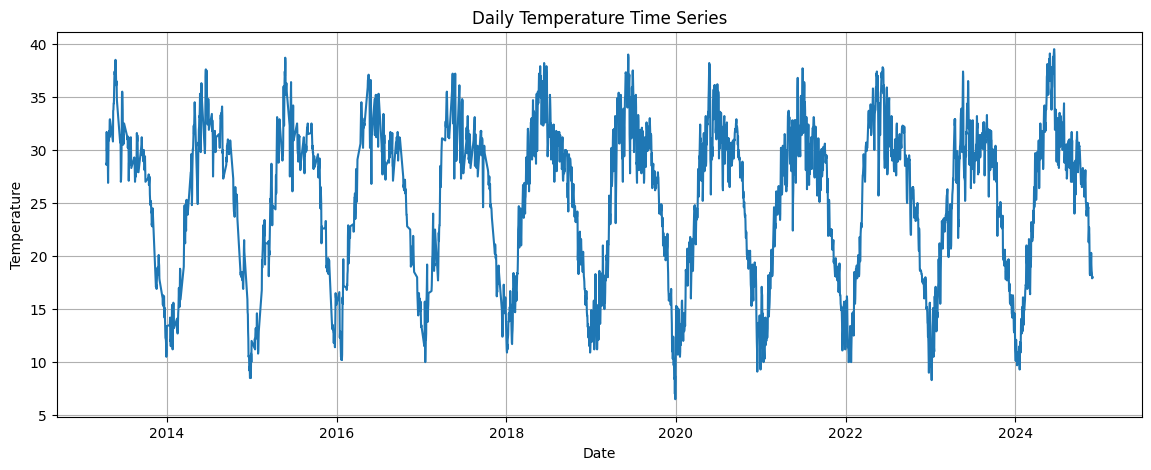

In [ ]:
plt.figure(figsize=(14,5))
plt.plot(df["temp"])
plt.title("Daily Temperature Time Series")
plt.xlabel("Date")
plt.ylabel("Temperature")
plt.grid()
plt.show()

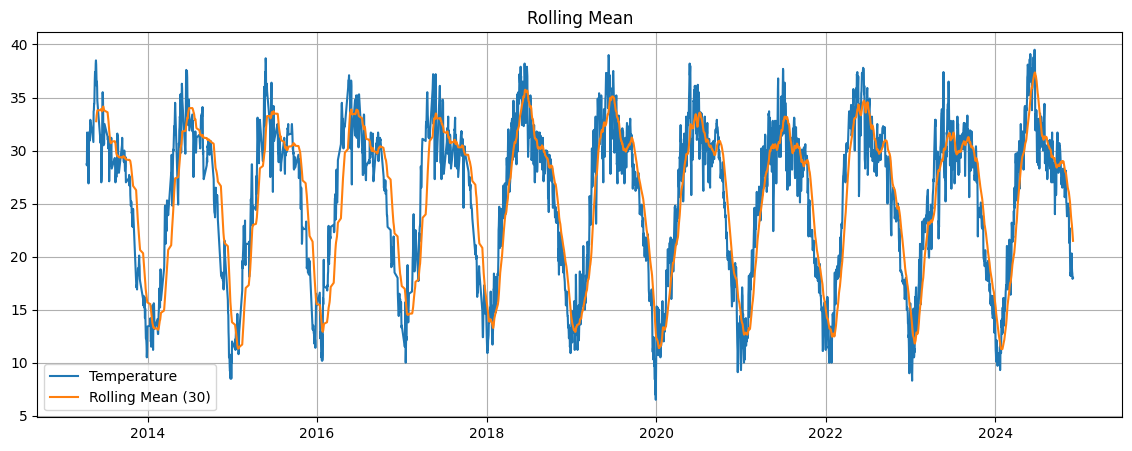

In [ ]:
df["rolling_mean"] = df["temp"].rolling(window=30).mean()

plt.figure(figsize=(14,5))
plt.plot(df["temp"], label="Temperature")
plt.plot(df["rolling_mean"], label="Rolling Mean (30)")
plt.title("Rolling Mean")
plt.legend()
plt.grid()
plt.show()

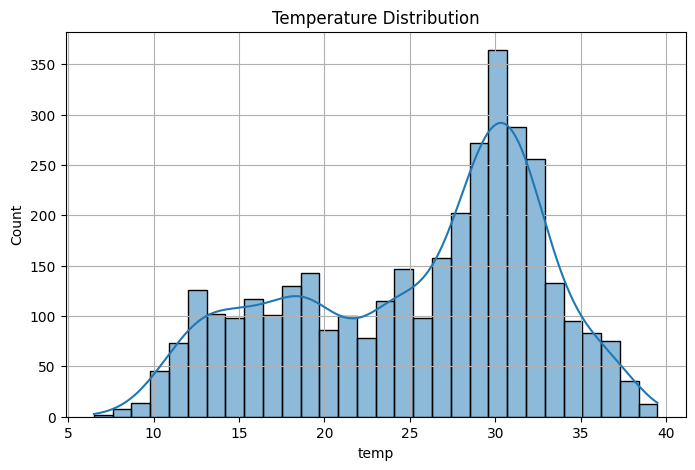

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df["temp"], bins=30, kde=True)
plt.title("Temperature Distribution")
plt.grid()
plt.show()

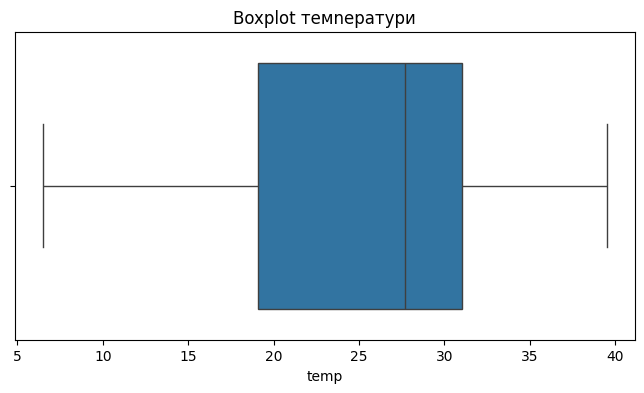

In [ ]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df["temp"])
plt.title("Boxplot тeмnepaтypи")
plt.show()

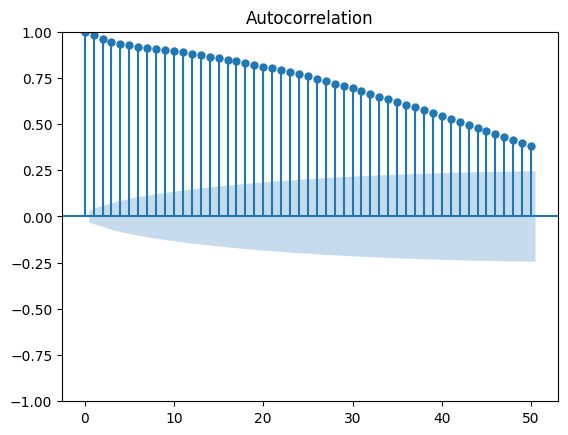

In [ ]:
plot_acf(df["temp"], lags=50)
plt.show()

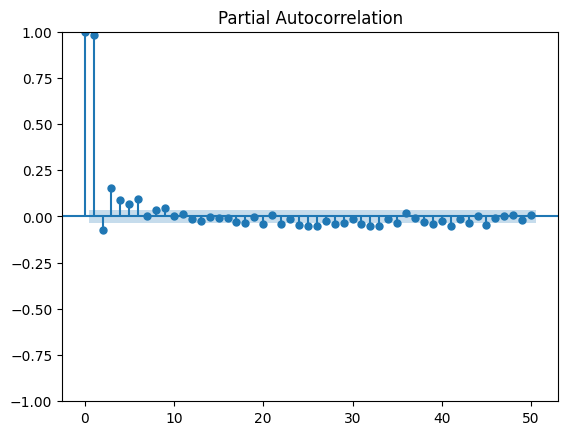

In [ ]:
plot_pacf(df["temp"], lags=50)
plt.show()

In [ ]:
target = df["temp"].copy()

split_index = int(len(target) * 0.8)

train = target.iloc[:split_index]
test = target.iloc[split_index:]

print("Train size:", len(train))
print("Test size:", len(test))


Train size: 2845
Test size: 712


https://developer.ibm.com/tutorials/awb-arima-models-in-python/

In [ ]:
arima_model = ARIMA(train, order=(5, 1, 2))
arima_fit = arima_model.fit()

arima_forecast = arima_fit.forecast(steps=len(test))
arima_forecast.index = test.index

print(arima_forecast.head())

DATE
2022-12-20    14.895737
2022-12-21    15.071189
2022-12-22    15.161451
2022-12-23    15.179429
2022-12-24    15.200756
Name: predicted_mean, dtype: float64


In [ ]:
print(arima_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 2886
Model:                 ARIMA(5, 1, 2)   Log Likelihood               -5037.296
Date:                Tue, 10 Mar 2026   AIC                          10090.593
Time:                        11:30:44   BIC                          10138.331
Sample:                             0   HQIC                         10107.798
                               - 2886                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1996      0.222      0.901      0.368      -0.235       0.634
ar.L2          0.1057      0.201      0.525      0.600      -0.289       0.500
ar.L3         -0.1086      0.049     -2.211      0.0

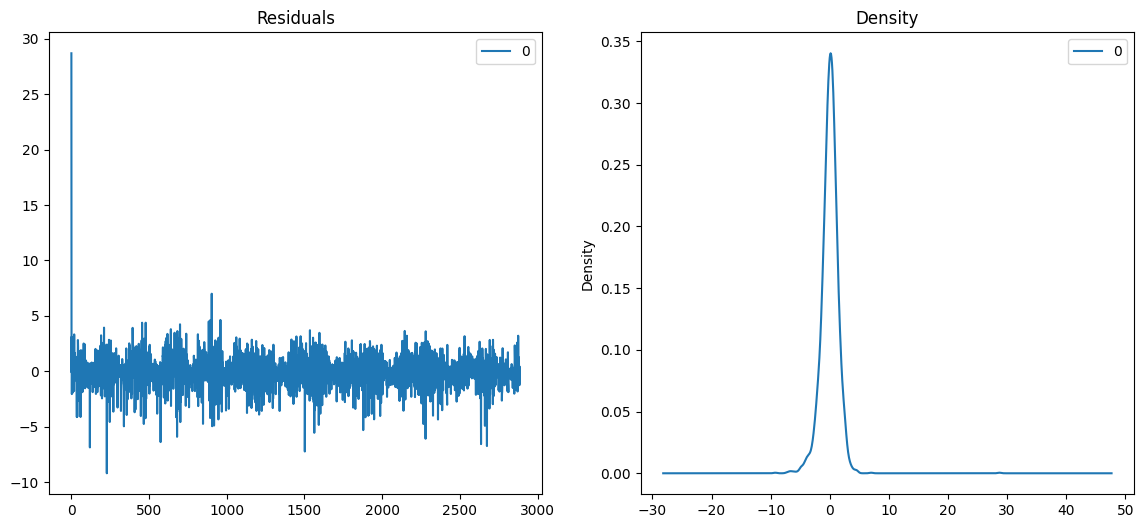

In [ ]:
import pandas as pd

residuals = pd.DataFrame(arima_fit.resid)
fig, ax = plt.subplots(1, 2, figsize=(14, 6))
residuals.plot(title="Residuals", ax=ax[0])
residuals.plot(kind='kde', title='Density', ax=ax[1])
plt.show()

In [ ]:
def mape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

arima_mae = mean_absolute_error(test, arima_forecast)
arima_rmse = np.sqrt(mean_squared_error(test, arima_forecast))
arima_mape = mape(test, arima_forecast)

print("ARIMA MAE:", arima_mae)
print("ARIMA RMSE:", arima_rmse)
print("ARIMA MAPE:", arima_mape)

ARIMA MAE: 10.92780939502283
ARIMA RMSE: 12.500912042764613
ARIMA MAPE: 39.59198711988373


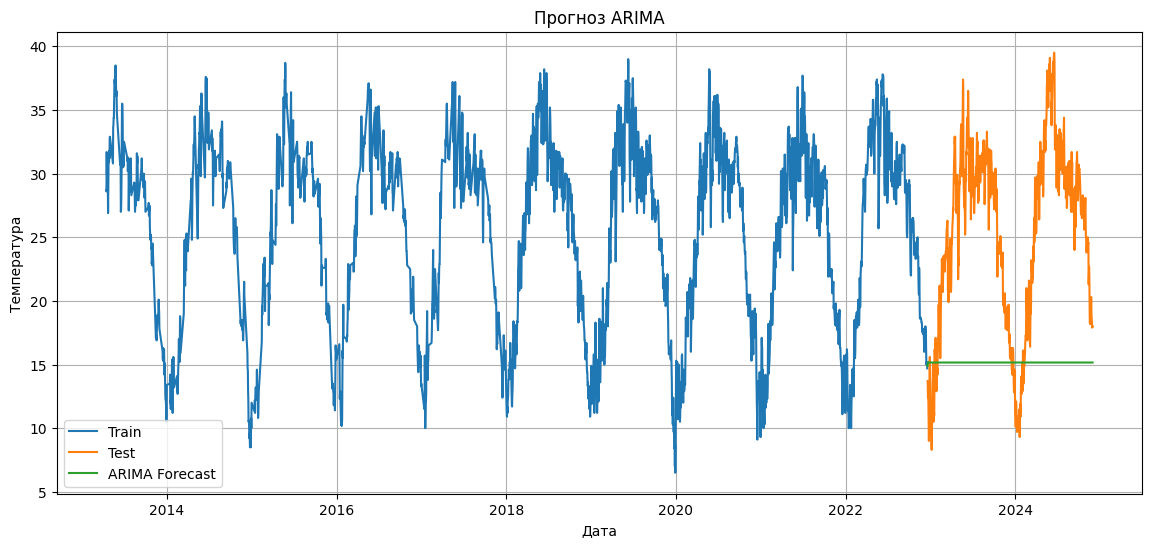

In [ ]:
plt.figure(figsize=(14, 6))
plt.plot(train.index, train, label="Train")
plt.plot(test.index, test, label="Test")
plt.plot(arima_forecast.index, arima_forecast, label="ARIMA Forecast")
plt.title("Прогноз ARIMA")
plt.xlabel("Дата")
plt.ylabel("Температура")
plt.legend()
plt.grid(True)
plt.show()

https://facebook.github.io/prophet/docs/quick_start.html

In [ ]:
prophet_df = df.reset_index()[["DATE", "temp"]].copy()
prophet_df.columns = ["ds", "y"]

prophet_train = prophet_df.iloc[:split_index].copy()
prophet_test = prophet_df.iloc[split_index:].copy()

In [ ]:
from prophet import Prophet

prophet_model = Prophet(
    daily_seasonality=False,
    weekly_seasonality=True,
    yearly_seasonality=True
)

prophet_model.fit(prophet_train)

In [ ]:
future = prophet_model.make_future_dataframe(periods=len(prophet_test), freq="D")
prophet_forecast_full = prophet_model.predict(future)

prophet_forecast = prophet_forecast_full[["ds", "yhat"]].tail(len(prophet_test)).copy()
prophet_forecast = prophet_forecast.set_index("ds")

prophet_test_indexed = prophet_test.set_index("ds")

In [ ]:
prophet_mae = mean_absolute_error(prophet_test_indexed["y"], prophet_forecast["yhat"])
prophet_rmse = np.sqrt(mean_squared_error(prophet_test_indexed["y"], prophet_forecast["yhat"]))
prophet_mape = mape(prophet_test_indexed["y"], prophet_forecast["yhat"])

print("Prophet MAE:", prophet_mae)
print("Prophet RMSE:", prophet_rmse)
print("Prophet MAPE:", prophet_mape)

Prophet MAE: 2.002177588726817
Prophet RMSE: 2.5872670693335067
Prophet MAPE: 9.014446237917445


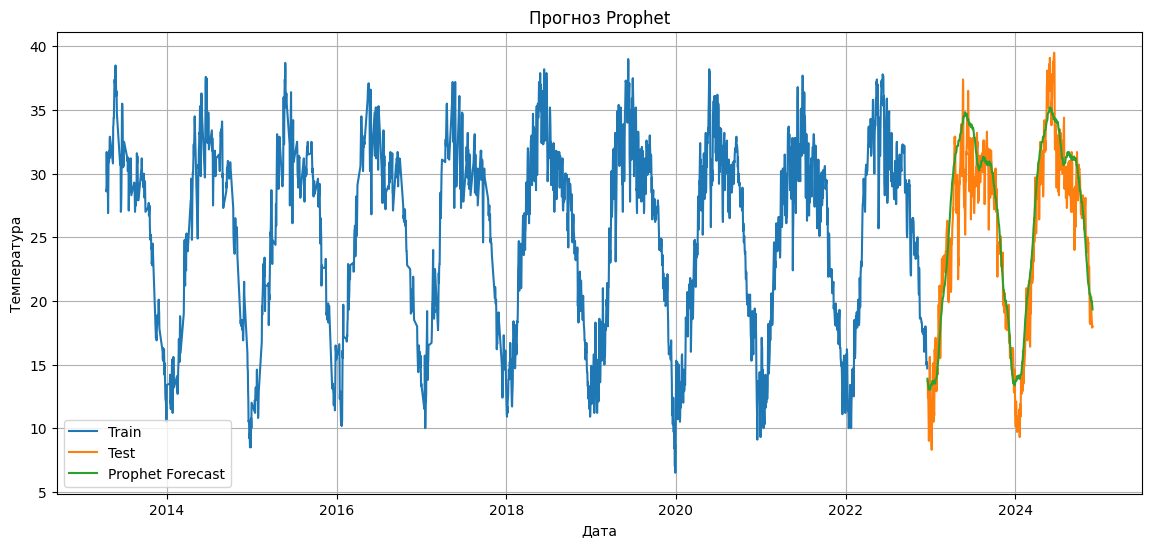

In [ ]:
plt.figure(figsize=(14, 6))
plt.plot(prophet_train["ds"], prophet_train["y"], label="Train")
plt.plot(prophet_test["ds"], prophet_test["y"], label="Test")
plt.plot(prophet_forecast.index, prophet_forecast["yhat"], label="Prophet Forecast")
plt.title("Прогноз Prophet")
plt.xlabel("Дата")
plt.ylabel("Температура")
plt.legend()
plt.grid(True)
plt.show()

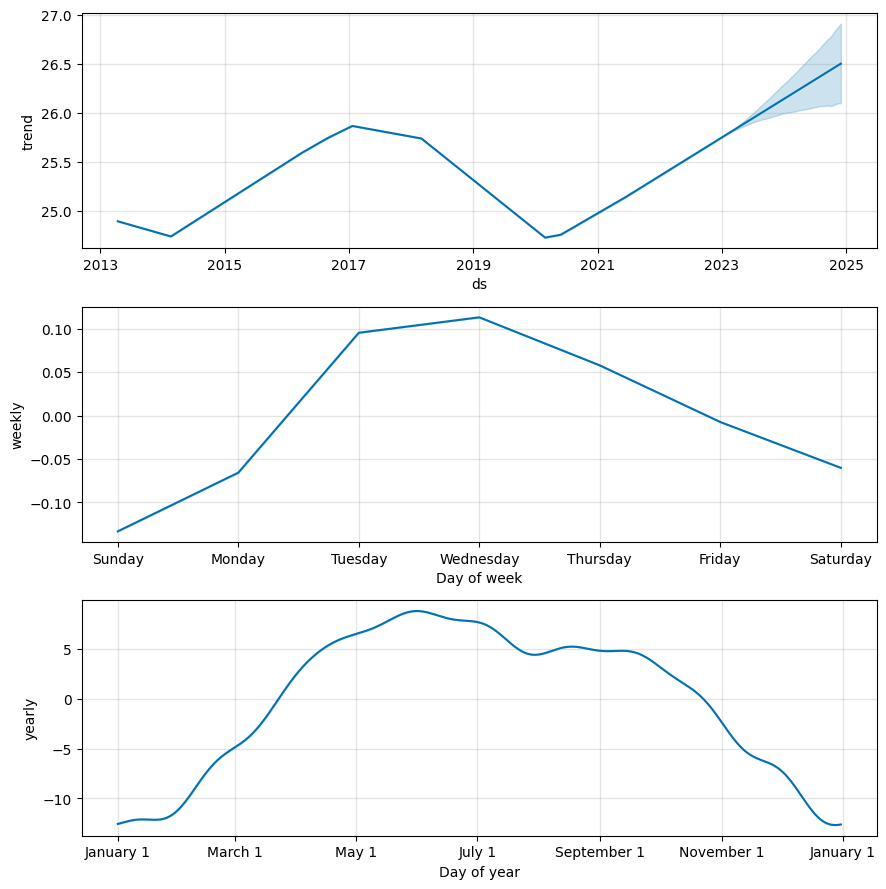

In [ ]:
prophet_model.plot_components(prophet_forecast_full)
plt.show()

In [ ]:
scaler = MinMaxScaler()
scaled_values = scaler.fit_transform(df[["temp"]])

sequence_length = 30

X = []
y = []

for i in range(sequence_length, len(scaled_values)):
    X.append(scaled_values[i-sequence_length:i, 0])
    y.append(scaled_values[i, 0])

X = np.array(X)
y = np.array(y)

X = X.reshape((X.shape[0], X.shape[1], 1))

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (3527, 30, 1)
y shape: (3527,)


In [ ]:
split_lstm = int(len(X) * 0.8)

X_train = X[:split_lstm]
X_test = X[split_lstm:]

y_train = y[:split_lstm]
y_test = y[split_lstm:]

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (2821, 30, 1)
X_test: (706, 30, 1)


In [ ]:
lstm_model = Sequential()
lstm_model.add(LSTM(50, return_sequences=True, input_shape=(X_train.shape[1], 1)))
lstm_model.add(LSTM(50))
lstm_model.add(Dense(1))

lstm_model.compile(optimizer="adam", loss="mse")

In [ ]:
history = lstm_model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/10
89/89 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - loss: 0.0401 - val_loss: 0.0048
Epoch 2/10
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0056 - val_loss: 0.0043
Epoch 3/10
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0048 - val_loss: 0.0040
Epoch 4/10
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0042 - val_loss: 0.0042
Epoch 5/10
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0044 - val_loss: 0.0044
Epoch 6/10
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0043 - val_loss: 0.0035
Epoch 7/10
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0036 - val_loss: 0.0028
Epoch 8/10
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0035 - val_loss: 0.0027
Epoch 9/10
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0032 - val_loss: 0.0027
Epoch 10/10
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0030 - val_loss: 0.0023


In [ ]:
lstm_model. summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 91,955 (359.20 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 61,304 (239.47 KB)

In [ ]:
lstm_pred_scaled = lstm_model.predict(X_test)

lstm_pred = scaler.inverse_transform(lstm_pred_scaled)
y_test_real = scaler.inverse_transform(y_test.reshape(-1, 1))

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


In [ ]:
lstm_dates = df.index[sequence_length:][split_lstm:]

In [ ]:
lstm_mae = mean_absolute_error(y_test_real, lstm_pred)
lstm_rmse = np.sqrt(mean_squared_error(y_test_real, lstm_pred))
lstm_mape = mape(y_test_real.flatten(), lstm_pred.flatten())

print("LSTM MAE:", lstm_mae)
print("LSTM RMSE:", lstm_rmse)
print("LSTM MAPE:", lstm_mape)

LSTM MAE: 1.209540159101189
LSTM RMSE: 1.5789849267872682
LSTM MAPE: 5.333936449126552


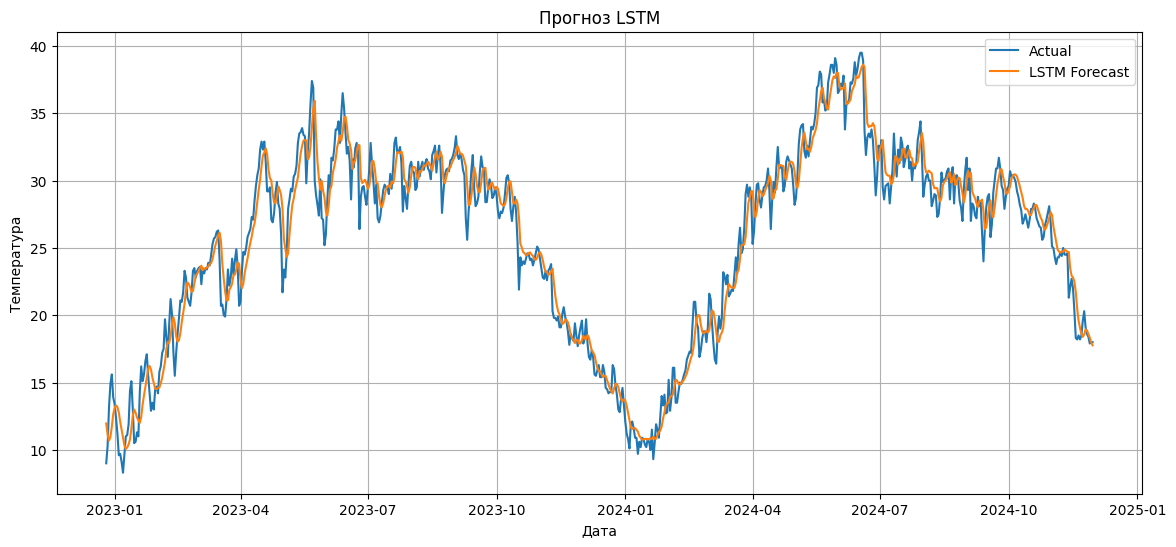

In [ ]:
plt.figure(figsize=(14, 6))
plt.plot(lstm_dates, y_test_real, label="Actual")
plt.plot(lstm_dates, lstm_pred, label="LSTM Forecast")
plt.title("Прогноз LSTM")
plt.xlabel("Дата")
plt.ylabel("Температура")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
results = pd.DataFrame({
    "Model": ["ARIMA", "Prophet", "LSTM"],
    "MAE": [arima_mae, prophet_mae, lstm_mae],
    "RMSE": [arima_rmse, prophet_rmse, lstm_rmse],
    "MAPE": [arima_mape, prophet_mape, lstm_mape]
})

print(results.sort_values("RMSE"))

     Model        MAE       RMSE       MAPE
2     LSTM   1.209540   1.578985   5.333936
1  Prophet   2.002178   2.587267   9.014446
0    ARIMA  10.927809  12.500912  39.591987


Висновок: У ході виконання лабораторної роботи було досліджено зміну температури в часі. Проведено візуалізацію часового ряду та застосовано моделі ARIMA, Prophet і LSTM для побудови прогнозу. Порівняння результатів за метриками MAE, RMSE та MAPE показало, що найбільш точні прогнози забезпечує модель LSTM.